Task 3 - Classification Models
1. Use a dataset (like Titanic) to build a classification model that predicts a categorical target variable (e.g., survived/not survived).

2. Compare at least two classifiers (e.g., Logistic Regression vs Decision Tree).

3. Evaluate your model using a confusion matrix, accuracy, precision, recall, and F1-score.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('train.csv')

In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df["Survived"].value_counts()

,count
Survived,
0,549
1,342


In [ ]:
df["Sex"].value_counts()

,count
Sex,
male,577
female,314


In [ ]:
df["Pclass"].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [ ]:
df["SibSp"].value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


In [ ]:
df["Parch"].value_counts()

,count
Parch,
0,678
1,118
2,80
5,5
3,5
4,4
6,1


In [ ]:
df["Cabin"].value_counts()

,count
Cabin,
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
D,3
...,...
E17,1
A24,1
C50,1


In [ ]:
df["cabin_alphabet"] = df["Cabin"].str[0]
df["cabin_alphabet"].value_counts()

,count
cabin_alphabet,
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


In [ ]:
df.groupby("cabin_alphabet")["Survived"].mean()

,Survived
cabin_alphabet,
A,0.466667
B,0.744681
C,0.593220
D,0.757576
E,0.750000
F,0.615385
G,0.500000
T,0.000000


In [ ]:
df.groupby("Embarked")["Survived"].mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


<Axes: xlabel='Age', ylabel='Count'>

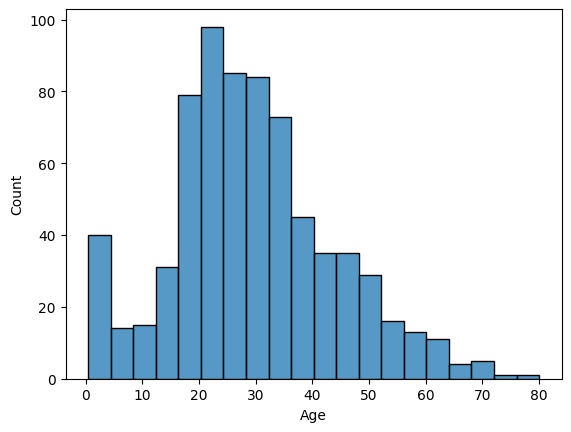

In [ ]:
sns.histplot(df["Age"])

<Axes: xlabel='Fare', ylabel='Count'>

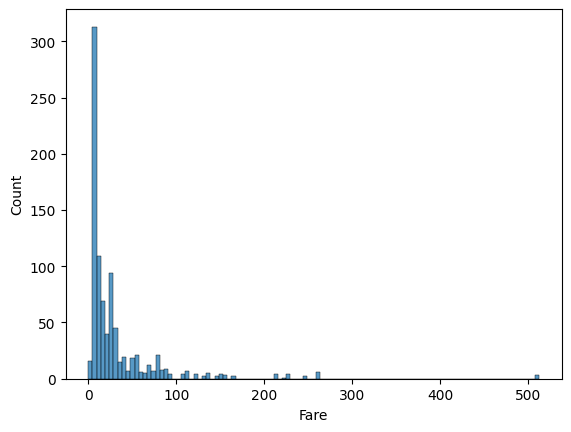

In [ ]:
sns.histplot(df["Fare"])

In [ ]:
df["Fare_log"] = np.log1p(df["Fare"])

<Axes: xlabel='Fare_log', ylabel='Count'>

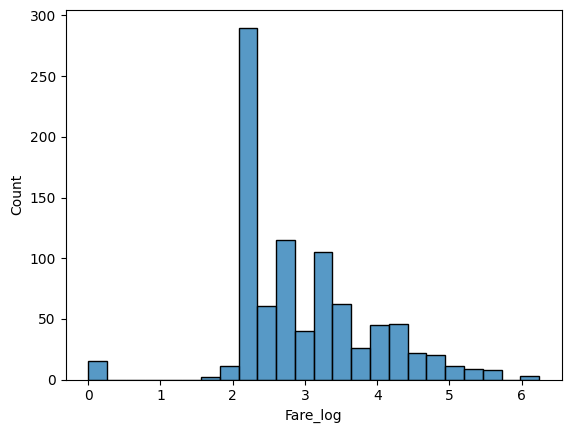

In [ ]:
sns.histplot(df["Fare_log"])

In [ ]:
# Removing Name and Ticket columns
df_1 = df.drop(columns = ["Name", "Ticket", "Fare", "Cabin"], axis = 1)
df_1

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked,cabin_alphabet,Fare_log
0,1,0,3,male,22.0,1,0,S,NaN,2.110213
1,2,1,1,female,38.0,1,0,C,C,4.280593
2,3,1,3,female,26.0,0,0,S,NaN,2.188856
3,4,1,1,female,35.0,1,0,S,C,3.990834
4,5,0,3,male,35.0,0,0,S,NaN,2.202765
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,S,NaN,2.639057
887,888,1,1,female,19.0,0,0,S,B,3.433987
888,889,0,3,female,NaN,1,2,S,NaN,3.196630
889,890,1,1,male,26.0,0,0,C,C,3.433987


In [ ]:
# applying ordinal encoding to object columns
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output = False, drop=None)
encoded = ohe.fit_transform(df_1[["Sex", "cabin_alphabet", "Embarked"]])
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(["Sex", "cabin_alphabet", "Embarked"])
)

In [ ]:
df_final = pd.concat([df_1.drop(["Sex", "cabin_alphabet", "Embarked"], axis=1), encoded_df], axis=1)

In [ ]:
df_final

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare_log,Sex_0.0,Sex_1.0,cabin_alphabet_0.0,...,cabin_alphabet_3.0,cabin_alphabet_4.0,cabin_alphabet_5.0,cabin_alphabet_6.0,cabin_alphabet_7.0,cabin_alphabet_nan,Embarked_0.0,Embarked_1.0,Embarked_2.0,Embarked_nan
0,1,0,3,22.0,1,0,2.110213,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,2,1,1,38.0,1,0,4.280593,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,3,1,3,26.0,0,0,2.188856,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,4,1,1,35.0,1,0,3.990834,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5,0,3,35.0,0,0,2.202765,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,2.639057,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
887,888,1,1,19.0,0,0,3.433987,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
888,889,0,3,NaN,1,2,3.196630,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
889,890,1,1,26.0,0,0,3.433987,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [54]:
df_final = df_final.drop("PassengerId", axis =1)

In [55]:
df_final.iloc[:,14].value_counts()

,count
cabin_alphabet_6.0,
0.0,887
1.0,4


In [73]:
df_final.fillna(0)

,Survived,Pclass,Age,SibSp,Parch,Fare_log,Sex_0.0,Sex_1.0,cabin_alphabet_0.0,cabin_alphabet_1.0,...,cabin_alphabet_3.0,cabin_alphabet_4.0,cabin_alphabet_5.0,cabin_alphabet_6.0,cabin_alphabet_7.0,cabin_alphabet_nan,Embarked_0.0,Embarked_1.0,Embarked_2.0,Embarked_nan
0,0,3,22.0,1,0,2.110213,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1,1,38.0,1,0,4.280593,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1,3,26.0,0,0,2.188856,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,1,1,35.0,1,0,3.990834,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,3,35.0,0,0,2.202765,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,2.639057,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
887,1,1,19.0,0,0,3.433987,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
888,0,3,0.0,1,2,3.196630,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
889,1,1,26.0,0,0,3.433987,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [65]:
## capping it with IQR
df_capped = df_final.copy()
for col in df_final.columns:
    Q1 = df[col].quantile(0.15)
    Q3 = df[col].quantile(0.85)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    df_capped[col] = np.where(df_final[col] > upper, upper,
                       np.where(df_final[col] < lower, lower, df_final[col]))

KeyError: 'Sex_0.0'

In [75]:
X = df_final.drop('Survived', axis=1)
y = df_final['Survived']

In [76]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((668, 20), (223, 20), (668,), (223,))

In [77]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

## Only scale continuous numeric features, not one-hot encoded features.

In [78]:
binary_cols = [col for col in X_train.columns if set(X_train[col].unique()) <= {0, 1}]
num_cols = [col for col in X_train.select_dtypes(include=['int64', 'float64']).columns
            if col not in binary_cols]

In [79]:
num_cols

['Pclass', 'Age', 'SibSp', 'Parch', 'Fare_log']

In [80]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

Text(0.5, 1.0, 'X_train After scaling')

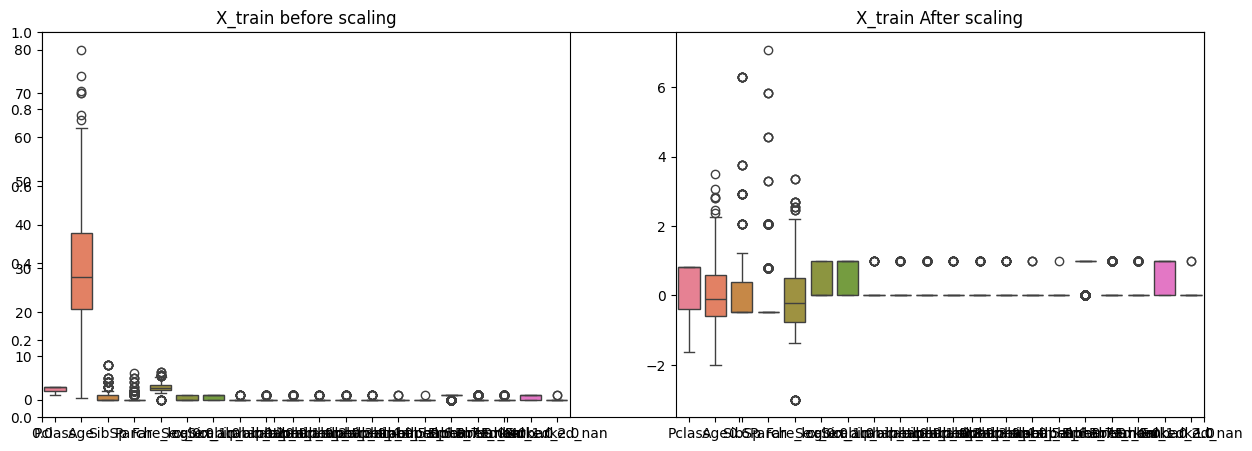

In [81]:
plt.subplots(figsize = (15,5))
plt.subplot(1,2,1)
sns.boxplot(X_train)
plt.title("X_train before scaling")
plt.subplot(1,2,2)
sns.boxplot(X_train_scaled)
plt.title("X_train After scaling")

In [82]:
X_train_scaled

,Pclass,Age,SibSp,Parch,Fare_log,Sex_0.0,Sex_1.0,cabin_alphabet_0.0,cabin_alphabet_1.0,cabin_alphabet_2.0,cabin_alphabet_3.0,cabin_alphabet_4.0,cabin_alphabet_5.0,cabin_alphabet_6.0,cabin_alphabet_7.0,cabin_alphabet_nan,Embarked_0.0,Embarked_1.0,Embarked_2.0,Embarked_nan
298,-1.620517,NaN,-0.467660,-0.468878,0.514139,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
884,0.809349,-0.304659,-0.467660,-0.468878,-0.876448,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
247,-0.405584,-0.373565,-0.467660,2.046870,-0.208664,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
478,0.809349,-0.511378,-0.467660,-0.468878,-0.818515,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
305,-1.620517,-1.963923,0.376656,2.046870,2.122020,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.809349,-0.580284,-0.467660,-0.468878,-0.803177,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
270,-1.620517,NaN,-0.467660,-0.468878,0.530190,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
860,0.809349,0.797843,1.220971,-0.468878,-0.234753,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
435,-1.620517,-1.062628,0.376656,2.046870,1.885856,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_train = log_reg.predict(X_train_scaled)
y_pred_test = log_reg.predict(X_test_scaled)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values